<a href="https://colab.research.google.com/github/Gizeh-Gutierrez/Maestria_programacion/blob/main/Sesion12_Clase_Analisis_Descriptivo_271752.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 12 — Análisis Descriptivo de Datos

**Notebook de clase — Sesión asíncrona**

Este notebook es el material principal de la sesión — contiene todo lo que necesitas para completarla, sin depender de la presentación.

## Contexto — ¿dónde estamos en la ruta de EDA?

Esta sesión inicia formalmente el Análisis Exploratorio de Datos: describir numérica y visualmente lo que hay en los datos, antes de buscar relaciones o modelos.

## Objetivos de la sesión

Al terminar esta sesión podrás:

1. Calcular e interpretar medidas de **tendencia central** (media, mediana, moda) — y saber cuándo divergen y por qué
2. Calcular e interpretar medidas de **dispersión** (rango, varianza, desviación estándar, rango intercuartílico)
3. Calcular e interpretar medidas de **forma** (asimetría, curtosis)
4. Acompañar cada medida con su **visualización** correspondiente (histograma, boxplot) usando `matplotlib`
5. Reinterpretar `.describe()` — un comando que ya conoces desde Sesión 10 — con el vocabulario estadístico formal que aprenderás hoy


> Nota: este notebook contiene 2 errores intencionales, cada uno marcado y explicado en la celda de Markdown que le sigue.

## Preparación

Retomamos **Customer Personality Analysis**, el dataset que ya perfilaste en Sesión 10 y Sesión 11. Ya sabes que sus tipos están ajustados y sus columnas categóricas revisadas — hoy nos enfocamos en las columnas **numéricas**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv'
df = pd.read_csv(url, sep=';')
df.shape

(2240, 29)

In [2]:
df[['Income', 'MntWines', 'MntFruits', 'MntMeatProducts']].head()

,Income,MntWines,MntFruits,MntMeatProducts
0,58138.0,635,88,546
1,46344.0,11,1,6
2,71613.0,426,49,127
3,26646.0,11,4,20
4,58293.0,173,43,118


---
## Bloque 1 — Medidas de tendencia central

> **Definición:** las medidas de tendencia central resumen un conjunto de datos numéricos en un solo valor que representa "lo típico". Las tres más comunes son la **media** (promedio), la **mediana** (valor central) y la **moda** (valor más frecuente) — y no siempre coinciden.

### Media vs. mediana — ¿cuándo divergen?

**Métodos de esta sección:**
- `Series.mean()` — calcula el promedio aritmético (suma de todos los valores ÷ número de valores). No requiere argumentos. Ignora automáticamente los valores ausentes (`NaN`).
- `Series.median()` — ordena todos los valores y regresa el que queda exactamente en el centro. Si hay un número par de valores, promedia los dos centrales.

**Predicción:** `Income` tiene 2,240 registros. ¿Crees que la media y la mediana serán parecidas, o muy distintas?

In [3]:
print('Media:  ', df['Income'].mean())
print('Mediana:', df['Income'].median())

Media:   52247.25135379061
Mediana: 51381.5


**Observación:** están bastante cerca (~52,247 vs. ~51,382) — a primera vista, nada alarmante. Pero mira el valor máximo de la columna:

In [4]:
df['Income'].max()

666666.0

**Para observar:** hay un registro con `Income = 666,666` — el segundo valor más alto de toda la columna es 162,397. Es casi con certeza un error de captura, no un ingreso real. Comparemos qué pasa con la media si lo excluimos:

In [5]:
media_con_outlier = df['Income'].mean()
media_sin_outlier = df[df['Income'] != 666666]['Income'].mean()

print(f'Media con el valor de 666,666:    {media_con_outlier:,.2f}')
print(f'Media sin el valor de 666,666:    {media_sin_outlier:,.2f}')
print(f'Diferencia:                        {media_con_outlier - media_sin_outlier:,.2f}')

Media con el valor de 666,666:    52,247.25
Media sin el valor de 666,666:    51,969.86
Diferencia:                        277.39


**Observación clave:** con 2,240 registros, un solo valor extremo apenas mueve la media (~277 unidades). La **mediana es robusta frente a outliers** — por eso ambas suelen usarse juntas: si divergen mucho, es señal de asimetría o de valores extremos (algo que profundizaremos en Bloque 3 y en la sesión de Datos Atípicos).

### Moda — la única medida que también aplica a categóricas

**Método de esta sección:**
- `Series.mode()` — regresa el valor (o los valores, si hay empate) que más veces se repite. A diferencia de `.mean()` y `.median()`, siempre regresa una `Series` (no un solo número), porque puede haber más de una moda.

In [6]:
df['Education'].mode()

,Education
0,Graduation


**🔍 Para observar:** `Graduation` es el nivel educativo más frecuente. A diferencia de la media y la mediana, la moda tiene sentido incluso para variables categóricas — por eso es la única de las tres que podrías calcular sobre, por ejemplo, `Marital_Status`.

**⚠️ Error intencional 1 — `TypeError`**

La siguiente celda intenta calcular la media de `Education`. `Education` es una columna categórica (tipo `category`, ajustada en Sesión 11) — promediar categorías no tiene sentido matemático, y pandas lo rechaza explícitamente en vez de inventar un resultado.

In [7]:
df['Education'] = df['Education'].astype('category')
df['Education'].mean()

TypeError: 'Categorical' with dtype category does not support reduction 'mean'

**Corrección:** la media (y la mediana) solo aplican a variables numéricas. Para `Education`, la medida de tendencia central correcta es la moda, que ya calculamos arriba.

In [13]:
# EJERCICIO: calcula la media, mediana y moda de MntWines.
# ¿Se parecen entre sí, o divergen como en Income? ¿Qué te sugiere eso sobre la forma de la distribución?
print("Media:", df["MntWines"].mean())
print("Mediana:", df["MntWines"].median())
print("Moda:",df["MntWines"].mode())


Media: 303.9357142857143
Mediana: 173.5
Moda 0    2
Name: MntWines, dtype: int64


La media, la mediana y la moda de MntWines no son muy parecidas. La moda es 2 y la media es mayor que la mediana, lo que indica una distribución asimétrica hacia la derecha con algunos clientes que gastan mucho más que la mayoría.

Muchos clientes gastan poco en vino 2, mientras que unos pocos clientes gastan cantidades muy altas, elevando el promedio.

---
## Bloque 2 — Medidas de dispersión

> **Definición:** las medidas de dispersión describen qué tan alejados están los datos entre sí — dos columnas pueden tener la misma media y verse completamente distintas si una está muy concentrada y otra muy dispersa.

### Rango, varianza y desviación estándar

**Métodos de esta sección:**
- `Series.max()` / `Series.min()` — regresan el valor más alto y más bajo de la columna. El rango es, simplemente, la resta de ambos.
- `Series.var()` — calcula la varianza: el promedio de qué tan lejos está cada valor de la media, elevado al cuadrado. Está en las unidades originales *al cuadrado* (por eso es difícil de interpretar directamente).
- `Series.std()` — la desviación estándar es la raíz cuadrada de la varianza. Vuelve a las unidades originales, por eso es la que se interpreta en la práctica.

In [14]:
rango = df['Income'].max() - df['Income'].min()
varianza = df['Income'].var()
desviacion = df['Income'].std()

print(f'Rango:               {rango:,.2f}')
print(f'Varianza:            {varianza:,.2f}')
print(f'Desviación estándar: {desviacion:,.2f}')

Rango:               664,936.00
Varianza:            633,683,788.58
Desviación estándar: 25,173.08


**Para observar:** el rango (664,936) está completamente dominado por el mismo valor extremo del Bloque 1 — es la medida de dispersión **más sensible a outliers** de las tres, porque solo usa el mínimo y el máximo, ignorando todo lo demás.

### Rango intercuartílico (IQR) — el puente hacia los atípicos

**Método de esta sección:**
- `Series.quantile(q)` — regresa el valor por debajo del cual cae una fracción `q` de los datos (`q` va de 0 a 1). `quantile(0.25)` es el percentil 25 (Q1); `quantile(0.75)` es el percentil 75 (Q3). El IQR es simplemente `Q3 − Q1`.

In [15]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1 (percentil 25): {Q1:,.2f}')
print(f'Q3 (percentil 75): {Q3:,.2f}')
print(f'IQR:                {IQR:,.2f}')

Q1 (percentil 25): 35,303.00
Q3 (percentil 75): 68,522.00
IQR:                33,219.00


**Por qué el IQR es distinto:** a diferencia del rango, el IQR describe la dispersión del **50% central** de los datos — ignora por diseño el 25% más bajo y el 25% más alto, así que un solo valor extremo casi no lo mueve. Es la medida de dispersión más robusta de las tres, y es exactamente la que usarás en la sesión de **Datos Atípicos** para definir los límites de un boxplot (`Q1 - 1.5×IQR` y `Q3 + 1.5×IQR`).

In [16]:
# EJERCICIO: calcula el rango, la varianza, la desviación estándar y el IQR de MntWines.
# Compara la sensibilidad del rango vs. el IQR frente a los valores extremos de esta columna.
# Rango
rango = df["MntWines"].max() - df["MntWines"].min()

# Varianza
varianza = df["MntWines"].var()

# Desviación estándar
desviacion = df["MntWines"].std()

# IQR
Q1 = df["MntWines"].quantile(0.25)
Q3 = df["MntWines"].quantile(0.75)
IQR = Q3 - Q1

print(f"Rango:               {rango:,.2f}")
print(f"Varianza:            {varianza:,.2f}")
print(f"Desviación estándar: {desviacion:,.2f}")
print(f"Q1:                  {Q1:,.2f}")
print(f"Q3:                  {Q3:,.2f}")
print(f"IQR:                 {IQR:,.2f}")


Rango:               1,493.00
Varianza:            113,297.80
Desviación estándar: 336.60
Q1:                  23.75
Q3:                  504.25
IQR:                 480.50


El rango de MntWines (1,493) indica una gran diferencia entre el gasto mínimo y máximo. El IQR (480.50) describe la dispersión del 50%  de los clientes. La gran diferencia entre rango e IQR, junto con la media (303.94) mayor que la mediana (173.5), sugiere que MntWines presenta una distribución asimétrica hacia la derecha con algunos clientes de gasto muy elevado que incrementan la dispersión.

---
## Bloque 3 — Medidas de forma

> **Definición:** las medidas de forma describen la silueta de una distribución — si es simétrica, si se inclina hacia un lado (asimetría), y qué tan "pesadas" son sus colas (curtosis).

### Asimetría (skewness)

**Método de esta sección:**
- `Series.skew()` — calcula un número que resume si la distribución se inclina hacia la izquierda (negativo), es simétrica (cercano a 0), o se inclina hacia la derecha (positivo). No requiere argumentos.

**Regla práctica:** cuando la media es mayor que la mediana, la distribución tiende a tener asimetría positiva (cola larga hacia la derecha) — justo lo que viste en Bloque 1 con `Income`.

In [17]:
print('Asimetría de Income (con outlier):   ', df['Income'].skew())
print('Asimetría de Income (sin outlier):   ', df[df['Income'] != 666666]['Income'].skew())

Asimetría de Income (con outlier):    6.763487372811116
Asimetría de Income (sin outlier):    0.34734967591402816


**Para observar:** la asimetría pasa de **6.76** a **0.35** al quitar un solo registro. Compara esto con lo que viste en Bloque 1: ese mismo outlier apenas movía la media (~277 unidades), pero aquí domina completamente el resultado. **La asimetría y la curtosis son mucho más sensibles a valores extremos que la media** — otra razón por la que revisar atípicos es un paso necesario antes de confiar en estas medidas.

**Método de esta sección:**
- `Series.kurt()` — calcula la curtosis: qué tan "pesadas" (con valores extremos) son las colas de la distribución comparadas con una distribución normal. No requiere argumentos.

In [18]:
print('Curtosis de Income (con outlier):', df['Income'].kurt())
print('Curtosis de Income (sin outlier):', df[df['Income'] != 666666]['Income'].kurt())

Curtosis de Income (con outlier): 159.6366995778005
Curtosis de Income (sin outlier): 0.7135488168867532


**Interpretación de curtosis:** valores cercanos a 0 indican colas similares a una distribución normal; valores altos (como 159.6) indican colas extremadamente pesadas — es decir, presencia de valores muy alejados del centro, coherente con lo que ya sabemos de este outlier.

In [19]:
# EJERCICIO: calcula la asimetría y curtosis de MntWines (sin quitar nada).
# ¿El valor te parece alto, moderado o bajo comparado con los de Income?
print("Asimetría de MntWines:", df["MntWines"].skew())
print("Curtosis de MntWines:", df["MntWines"].kurt())


Asimetría de MntWines: 1.1757705637550502
Curtosis de MntWines: 0.5987435935182441


MntWines presenta una asimetría positiva moderada (1.18), lo que indica una cola hacia la derecha y confirma que algunos clientes gastan mucho más en vino que la mayoría. Su curtosis (0.60) es  baja y cercana a la observada en Income después de eliminar el outlier extremo. Por tanto, aunque existen valores altos en MntWines, no hay evidencia de un valor tan dominante como el de 666,666 en Income. La distribución está sesgada a la derecha, pero no presenta colas extremas.

---
## Bloque 4 — Visualización

Los números de los Bloques 1-3 resumen una distribución, pero pueden ocultar su forma real — dos distribuciones pueden compartir media, mediana y desviación estándar y verse completamente distintas. Por eso la visualización es parte constitutiva del análisis descriptivo, no un adorno.

### Histograma — con `.plot()` de pandas

**Método de esta sección:**
- `Series.plot(kind='hist', bins=N)` — dibuja un histograma directamente desde una columna del DataFrame. `bins` controla en cuántas barras se divide el rango de valores (más bins = más detalle, pero también más ruido visual). Por debajo, usa `matplotlib` sin que tengas que importarlo por separado.

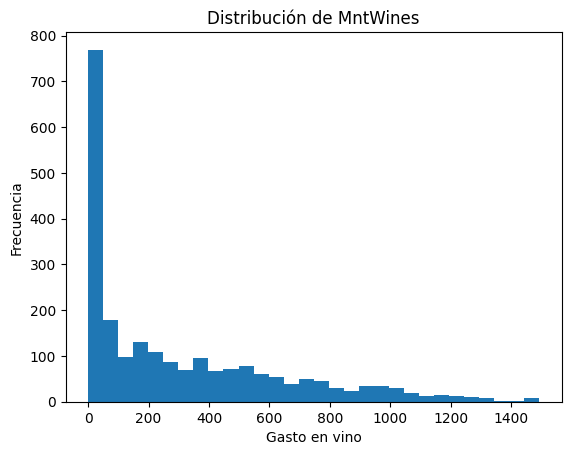

In [20]:
df['MntWines'].plot(kind='hist', bins=30, title='Distribución de MntWines')
plt.xlabel('Gasto en vino')
plt.ylabel('Frecuencia')
plt.show()

**🔍 Para observar:** el histograma confirma visualmente la asimetría positiva que calculaste en Bloque 3 — la mayoría de los clientes gasta poco en vino, y una cola larga de clientes gasta mucho más, estirando la distribución hacia la derecha.

### El mismo histograma, con `matplotlib.pyplot` directamente

`.plot()` de pandas es, por debajo, una llamada a `matplotlib`. Esta es la versión explícita — más código, pero más control.

**Métodos de esta sección:**
- `plt.hist(datos, bins=N, color=..., edgecolor=...)` — la versión directa de matplotlib. Recibe la columna como primer argumento (en vez de llamarse sobre ella).
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()` — agregan título y etiquetas a los ejes del gráfico más reciente.
- `plt.show()` — renderiza el gráfico en pantalla.

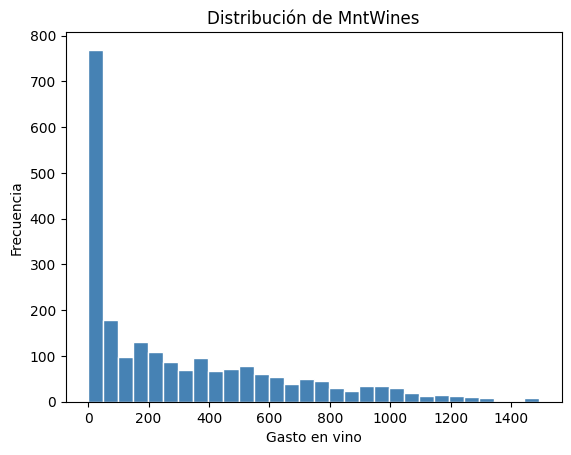

In [21]:
plt.hist(df['MntWines'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de MntWines')
plt.xlabel('Gasto en vino')
plt.ylabel('Frecuencia')
plt.show()

**⚠️ Error intencional 2 — `KeyError`**

Queremos construir el mismo histograma para `Income`, pero escribimos el nombre de la columna con minúscula.

In [22]:
plt.hist(df['income'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de Income')
plt.show()

KeyError: 'income'

**Corrección:** el nombre real de la columna es `Income`, con mayúscula — igual que los errores de nombre de columna que ya viste en sesiones anteriores, pandas distingue mayúsculas de minúsculas.

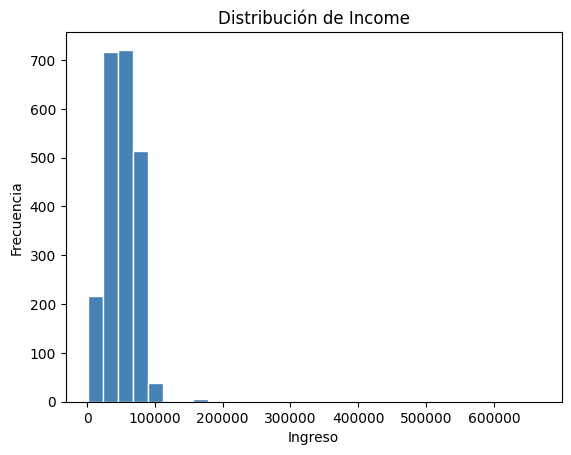

In [23]:
plt.hist(df['Income'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de Income')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()

### Boxplot — resumen visual de cinco números

El boxplot dibuja Q1, la mediana, Q3, y los "bigotes" (basados en el IQR que calculaste en Bloque 2). Los puntos fuera de los bigotes son candidatos a atípicos — los verás con detalle en la próxima etapa del curso.

**Anatomía de un boxplot:**

| Parte | Qué representa |
|---|---|
| Bigote inferior | `Q1 − 1.5 × IQR` (límite, no siempre alcanzado por un dato real) |
| Borde inferior de la caja (Q1) | Percentil 25 — 25% de los datos por debajo |
| Línea central de la caja | Mediana (percentil 50) |
| Borde superior de la caja (Q3) | Percentil 75 — 25% de los datos por encima |
| Bigote superior | `Q3 + 1.5 × IQR` |
| Puntos aislados | Valores por fuera de los bigotes — candidatos a atípicos |

**Métodos de esta sección:**
- `Series.plot(kind='box')` — dibuja el boxplot directamente desde una columna, usando `.plot()` de pandas.
- `plt.boxplot(datos)` — la versión directa de matplotlib, recibe la columna como argumento.

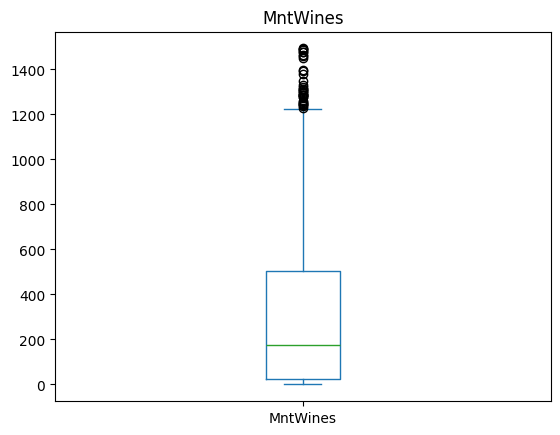

In [24]:
df['MntWines'].plot(kind='box', title='MntWines')
plt.show()

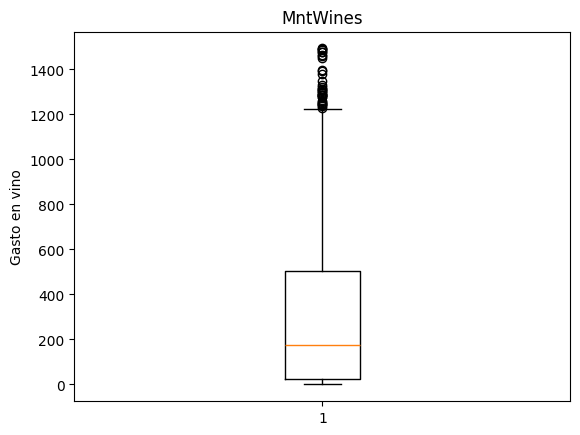

In [25]:
plt.boxplot(df['MntWines'])
plt.title('MntWines')
plt.ylabel('Gasto en vino')
plt.show()

**🔍 Para observar:** los puntos por encima del bigote superior son los mismos clientes que generan la cola larga que viste en el histograma y la asimetría positiva que calculaste en Bloque 3 — tres formas distintas (número, forma, imagen) de ver **el mismo fenómeno**.

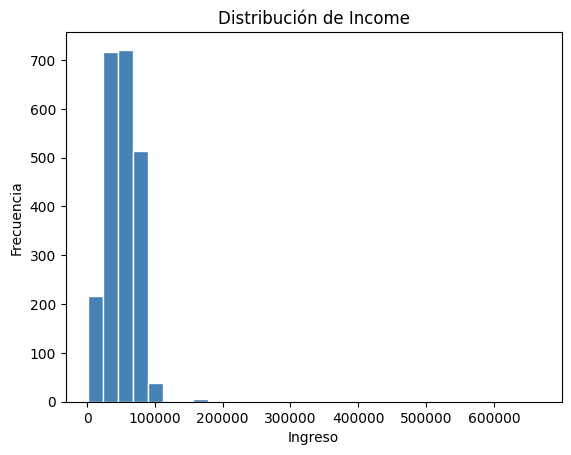

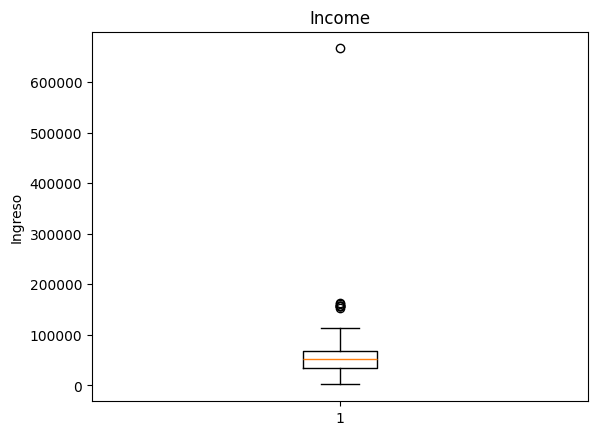

In [26]:
# EJERCICIO: construye el histograma y el boxplot de Income.
# ¿El outlier de 666,666 es visible en ambos gráficos? ¿En cuál se nota más?

# Histograma
plt.hist(df['Income'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de Income')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot
plt.boxplot(df['Income'].dropna())
plt.title('Income')
plt.ylabel('Ingreso')
plt.show()

El valor de 666,666 es visible tanto en el histograma como en el boxplot.se aprecia mucho más claramente en el boxplot porque aparece como un punto aislado muy por encima del resto de los datos y fuera de los límites definidos por el IQR. En el histograma también se observa, pero principalmente porque estira el eje horizontal y comprime visualmente la distribución principal de ingresos. El boxplot es la herramienta más efectiva para identificar este valor como un posible dato atípico.

---
## Cierre — `.describe()`, ahora con vocabulario estadístico

Ya usabas `.describe()` desde Sesión 10. Ahora que conoces el significado formal de cada medida, vuelve a verlo:

In [27]:
df[['Income', 'MntWines', 'MntFruits']].describe()

,Income,MntWines,MntFruits
count,2216.000000,2240.000000,2240.000000
mean,52247.251354,303.935714,26.302232
std,25173.076661,336.597393,39.773434
min,1730.000000,0.000000,0.000000
25%,35303.000000,23.750000,1.000000
50%,51381.500000,173.500000,8.000000
75%,68522.000000,504.250000,33.000000
max,666666.000000,1493.000000,199.000000


Cada columna de esa tabla ya no es solo "un número que pandas calculó" — ahora sabes que `mean` puede estar distorsionada por un valor extremo, que `50%` (la mediana) es más robusta, que `std` está inflada por el mismo outlier que viste en Bloque 1, y que la diferencia entre `75%` y `25%` es el IQR que vas a reutilizar en la siguiente etapa del curso.
